### Introdução

O conjunto de dados Global Data on Sustainable Energy, disponibilizado no Kaggle, reúne informações detalhadas sobre consumo energético, fontes renováveis, emissões de CO₂, acesso à eletricidade e indicadores econômicos para países de todo o mundo. Esses dados são fundamentais para o monitoramento do progresso em sustentabilidade energética, planejamento de políticas públicas e análise comparativa entre diferentes regiões e faixas de renda.

A natureza quantitativa dessas informações permite a aplicação de métodos estatísticos adequados para **variáveis contínuas positivas**, com destaque para os Modelos Lineares Generalizados (GLM), que possibilitam investigar fatores associados a indicadores energéticos e econômicos.


### O Banco de Dados

O banco de dados contém registros anuais agregados por país, contemplando variáveis como população, consumo total de energia, consumo de energia renovável, emissões de CO₂, acesso à eletricidade, intensidade energética e PIB. Também inclui informações categóricas sobre região geográfica e faixa de renda, permitindo comparações espaciais e socioeconômicas.

Essa estrutura possibilita a **análise de variáveis contínuas relacionadas à energia**, como consumo energético, intensidade energética e emissões de CO₂, bem como a investigação de padrões em diferentes contextos socioeconômicos e geográficos.


### Modelagem Estatística (GLM)

A variável resposta principal é caracterizada como **uma variável contínua, estritamente positiva e assimétrica**, o que justifica a utilização da distribuição Gamma no contexto dos Modelos Lineares Generalizados (GLM). Essa abordagem é particularmente adequada para modelar grandezas como consumo de energia, intensidade energética ou emissões, que não assumem valores negativos e frequentemente apresentam assimetria à direita.

Nesse contexto, a análise é conduzida por meio de um **GLM com distribuição Gamma e função de ligação apropriada (comumente a ligação log), permitindo modelar a relação entre a variável resposta e um conjunto de covariáveis explicativas**, como população, consumo energético, emissões de CO₂, acesso à eletricidade, PIB, região e faixa de renda.

Diferentemente dos modelos de contagem, como Poisson ou Binomial Negativa, a modelagem com distribuição Gamma é mais adequada para capturar a variabilidade de dados contínuos positivos, especialmente quando há heterocedasticidade (variância crescente com a média). Essa abordagem possibilita a identificação de fatores associados ao comportamento dos indicadores energéticos e a avaliação de diferenças entre países e regiões.


A partir do conjunto de dados **Global Data on Sustainable Energy (2000–2020)**, foram selecionadas as variáveis utilizadas na modelagem da **intensidade energética**. O conjunto original contém aproximadamente 3.649 observações e, após o processo de limpeza e remoção de dados ausentes ou inconsistentes, passou a contar com 3.026 observações.

Algumas das variáveis utilizadas estão descritas a seguir:


| Variável                                      | Tipo de dado | Natureza     | Característica                                                                                                                                                                                                                                              |
| --------------------------------------------- | ------------ | ------------ | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **intensidade_energia_mj_por_pib_ppp**        | Contínua     | Quantitativa | Quantidade de energia consumida **em megajoules (MJ)** para gerar **1 unidade de PIB em dólares internacionais ajustados por paridade do poder de compra (US$ PPP)**; utilizada como **variável resposta**, representando o nível de eficiência energética. |
| **acesso_combustiveis_limpos_para_conzinhar** | Contínua     | Quantitativa | Percentual (%) da população com acesso a combustíveis limpos e tecnologias adequadas para cozinhar; indicador do nível de desenvolvimento energético doméstico e da transição para fontes menos poluentes.                                                  |
| **pct_acesso_eletricidade**                   | Contínua     | Quantitativa | Percentual (%) da população com acesso à eletricidade; reflete o grau de universalização da infraestrutura elétrica.                                                                                                                                        |
| **pib_per_capita**                            | Contínua     | Quantitativa | Produto Interno Bruto per capita expresso em **dólares internacionais constantes ajustados por paridade do poder de compra (US$ PPP por pessoa)**; representa o nível médio de desenvolvimento econômico.                                                   |
| **consumo_energia_primaria_kwh_per_capita**   | Contínua     | Quantitativa | Consumo de energia primária por habitante, medido em **quilowatt-hora por pessoa (kWh per capita)**; reflete a intensidade do uso de energia nas atividades econômicas e sociais.                                                                           |
| **co2_emissoes_tm_per_capita**                | Contínua     | Quantitativa | **Atenção:** apesar do nome sugerir “por habitante”, os valores indicam que a variável está em **emissões totais de CO₂ (provavelmente em quilotoneladas – kt)**; representa o volume agregado de emissões do país, não uma medida per capita direta.       |
| **densidade_populacional**                    | Contínua     | Quantitativa | Número de habitantes por **quilômetro quadrado (hab/km²)**; variável associada ao padrão de ocupação territorial e potencial influência sobre consumo energético e eficiência no uso de recursos.                                                           |
                                                |




In [25]:
import pandas as pd

df= pd.read_csv(
    "global-data-on-sustainable-energy (1).csv",
    sep=",",
    encoding="latin1",
    low_memory=False
)


In [26]:
import numpy as np

# Renomear colunas (português, mas fiel ao original)
df = df.rename(columns={
    "Access to electricity (% of population)": "pct_acesso_eletricidade",
    "Primary energy consumption per capita (kWh/person)": "consumo_energia_primaria_kwh_per_capita",
    "Renewables (% equivalent primary energy)": "pct_energia_renovaveis_primaria",
    "Value_co2_emissions_kt_by_country": "co2_emissoes_tm_per_capita",
    "Energy intensity level of primary energy (MJ/$2017 PPP GDP)": "intensidade_energia_mj_por_pib_ppp", 
    "Renewable-electricity-generating-capacity-per-capita": "capacidade_eletrica_renovavel_per_capita", #per_capita ou por_pessoa é mesma coisa
    "gdp_per_capita": "pib_per_capita",
    "Density\\n(P/Km2)": "densidade_populacional",
    "Access to clean fuels for cooking": "acesso_combustiveis_limpos_para_conzinhar",
    "Financial flows to developing countries (US $)": "fluxo_financeiro_energia_limpa",
    "Electricity from nuclear (TWh)" : "Eletricidade_energia_nuclear",
    "Electricity from fossil fuels (TWh)": "Eletricidade_energia_combustiveis_fosseis",
    "Electricity from renewables (TWh)": "Eletricidade_energia_fontes_renovaveis" 
})

# Seleção de variáveis
cols = [
    "pib_per_capita",
    "consumo_energia_primaria_kwh_per_capita",
   # "pct_energia_renovaveis_primaria",
    "co2_emissoes_tm_per_capita",
    "pct_acesso_eletricidade",
    "intensidade_energia_mj_por_pib_ppp",
    #"capacidade_eletrica_renovavel_per_capita",
    "densidade_populacional",
    "acesso_combustiveis_limpos_para_conzinhar",
   # "fluxo_financeiro_energia_limpa",
    #"Eletricidade_energia_nuclear",
    #"Eletricidade_energia_combustiveis_fosseis",
    #"Eletricidade_energia_fontes_renovaveis" 
]

df['densidade_populacional'] = df['densidade_populacional'].str.replace(',', '').astype(float)

# Conversão de tipos
df_energy_filtrado = df[cols].copy()
df_energy_filtrado = df_energy_filtrado.astype({
    "pib_per_capita": float,
    "consumo_energia_primaria_kwh_per_capita": float,
  #  "pct_energia_renovaveis_primaria": float,
    "co2_emissoes_tm_per_capita": float,
    "pct_acesso_eletricidade": float,
    "intensidade_energia_mj_por_pib_ppp": float,
  #  "capacidade_eletrica_renovavel_per_capita": float,
     "acesso_combustiveis_limpos_para_conzinhar" : float,
  #  "fluxo_financeiro_energia_limpa" : float,
    "densidade_populacional": float
  #  "Eletricidade_energia_nuclear" : float,
  #  "Eletricidade_energia_combustiveis_fosseis" : float,
  #  "Eletricidade_energia_fontes_renovaveis"  : float
})

#print(df.columns.tolist())

# Remover outros NA
df_energy_filtrado = df_energy_filtrado.dropna()
df_energy_filtrado.head(10)



,pib_per_capita,consumo_energia_primaria_kwh_per_capita,co2_emissoes_tm_per_capita,pct_acesso_eletricidade,intensidade_energia_mj_por_pib_ppp,densidade_populacional,acesso_combustiveis_limpos_para_conzinhar
2,179.426579,210.86215,1029.999971,9.409158,1.40,60.0,8.20
3,190.683814,229.96822,1220.000029,14.738506,1.40,60.0,9.50
4,211.382074,204.23125,1029.999971,20.064968,1.20,60.0,10.90
5,242.031313,252.06912,1549.999952,25.390894,1.41,60.0,12.20
6,263.733602,304.42090,1759.999990,30.718690,1.50,60.0,13.85
7,359.693158,354.27990,1769.999981,36.051010,1.53,60.0,15.30
8,364.663542,607.83350,3559.999943,42.400000,1.94,60.0,16.70
9,437.268740,975.04816,4880.000114,46.740050,2.25,60.0,18.40
10,543.306526,1182.89200,7110.000134,42.700000,2.46,60.0,20.00
11,591.190030,1436.11430,8930.000305,43.222020,3.23,60.0,21.80


### Importância das Medidas Descritivas

As medidas descritivas são utilizadas para caracterizar a estrutura das variáveis do estudo. Variáveis numéricas, como população, consumo total de energia, consumo de energia renovável, emissões de CO₂ e PIB, são descritas por medidas de tendência central, dispersão e amplitude, permitindo resumir sua distribuição entre os países.

Variáveis categóricas, como região geográfica e faixa de renda, são descritas por meio de frequências absolutas e relativas, possibilitando a compreensão da distribuição das categorias. Essas descrições fornecem uma visão inicial dos padrões de implementação de projetos de energia renovável e permitem identificar possíveis agrupamentos ou desigualdades entre países e regiões.

In [27]:
# Estatísticas descritivas básicas
tabela_descritiva = df_energy_filtrado[cols].describe().round(2)

# Aplicando estilo
tabela_descritiva.style.format("{:.2f}") \
                       .set_caption("Estatísticas Descritivas com Skewness e Kurtosis") 


,pib_per_capita,consumo_energia_primaria_kwh_per_capita,co2_emissoes_tm_per_capita,pct_acesso_eletricidade,intensidade_energia_mj_por_pib_ppp,densidade_populacional,acesso_combustiveis_limpos_para_conzinhar
count,3026.00,3026.00,3026.00,3026.00,3026.00,3026.00,3026.00
mean,12286.48,26064.98,168602.15,77.46,5.39,221.96,62.52
std,18333.74,36712.20,797367.57,31.09,3.51,723.72,39.04
min,111.93,0.00,10.00,1.25,1.03,2.00,0.00
25%,1254.57,2863.42,2190.00,56.18,3.30,30.00,22.50
50%,4170.90,12105.25,10975.00,97.46,4.40,83.00,81.62
75%,14316.23,32294.35,64682.50,100.00,6.06,203.00,100.00
max,123514.20,262585.70,10707219.73,100.00,32.57,8358.00,100.00


As estatísticas indicam **forte desigualdade entre os países**.

O **PIB per capita (US$ PPP)** e o **consumo de energia (kWh per capita)** têm médias bem maiores que as medianas, mostrando **assimetria à direita**: poucos países ricos concentram altos valores.

As **emissões de CO₂** são ainda mais concentradas, com valores extremos muito elevados, sugerindo que representam **emissões totais (em kt)** e não por habitante.

Já o **acesso à eletricidade (%)** e aos **combustíveis limpos (%)** apresentam **assimetria à esquerda**, indicando que a maioria dos países está próxima de 100%, com poucos ainda em níveis baixos.

A **intensidade energética (MJ por US$ PPP)** também é assimétrica à direita, mostrando que alguns países são **menos eficientes no uso de energia**.

Por fim, a **densidade populacional (hab/km²)** é bastante dispersa, com poucos países muito densos.



### Entendo a distribuição dos dados via Pair plot

O pair plot é uma ferramenta gráfica que permite visualizar a distribuição de variáveis numéricas e as relações entre elas. Ele possibilita observar a dispersão dos dados, a presença de valores atípicos e possíveis padrões de associação entre as variáveis.

No contexto dos dados analisados, pode ser utilizado para explorar as variáveis, fornecendo insights sobre variação, tendência e possíveis relações estruturais.

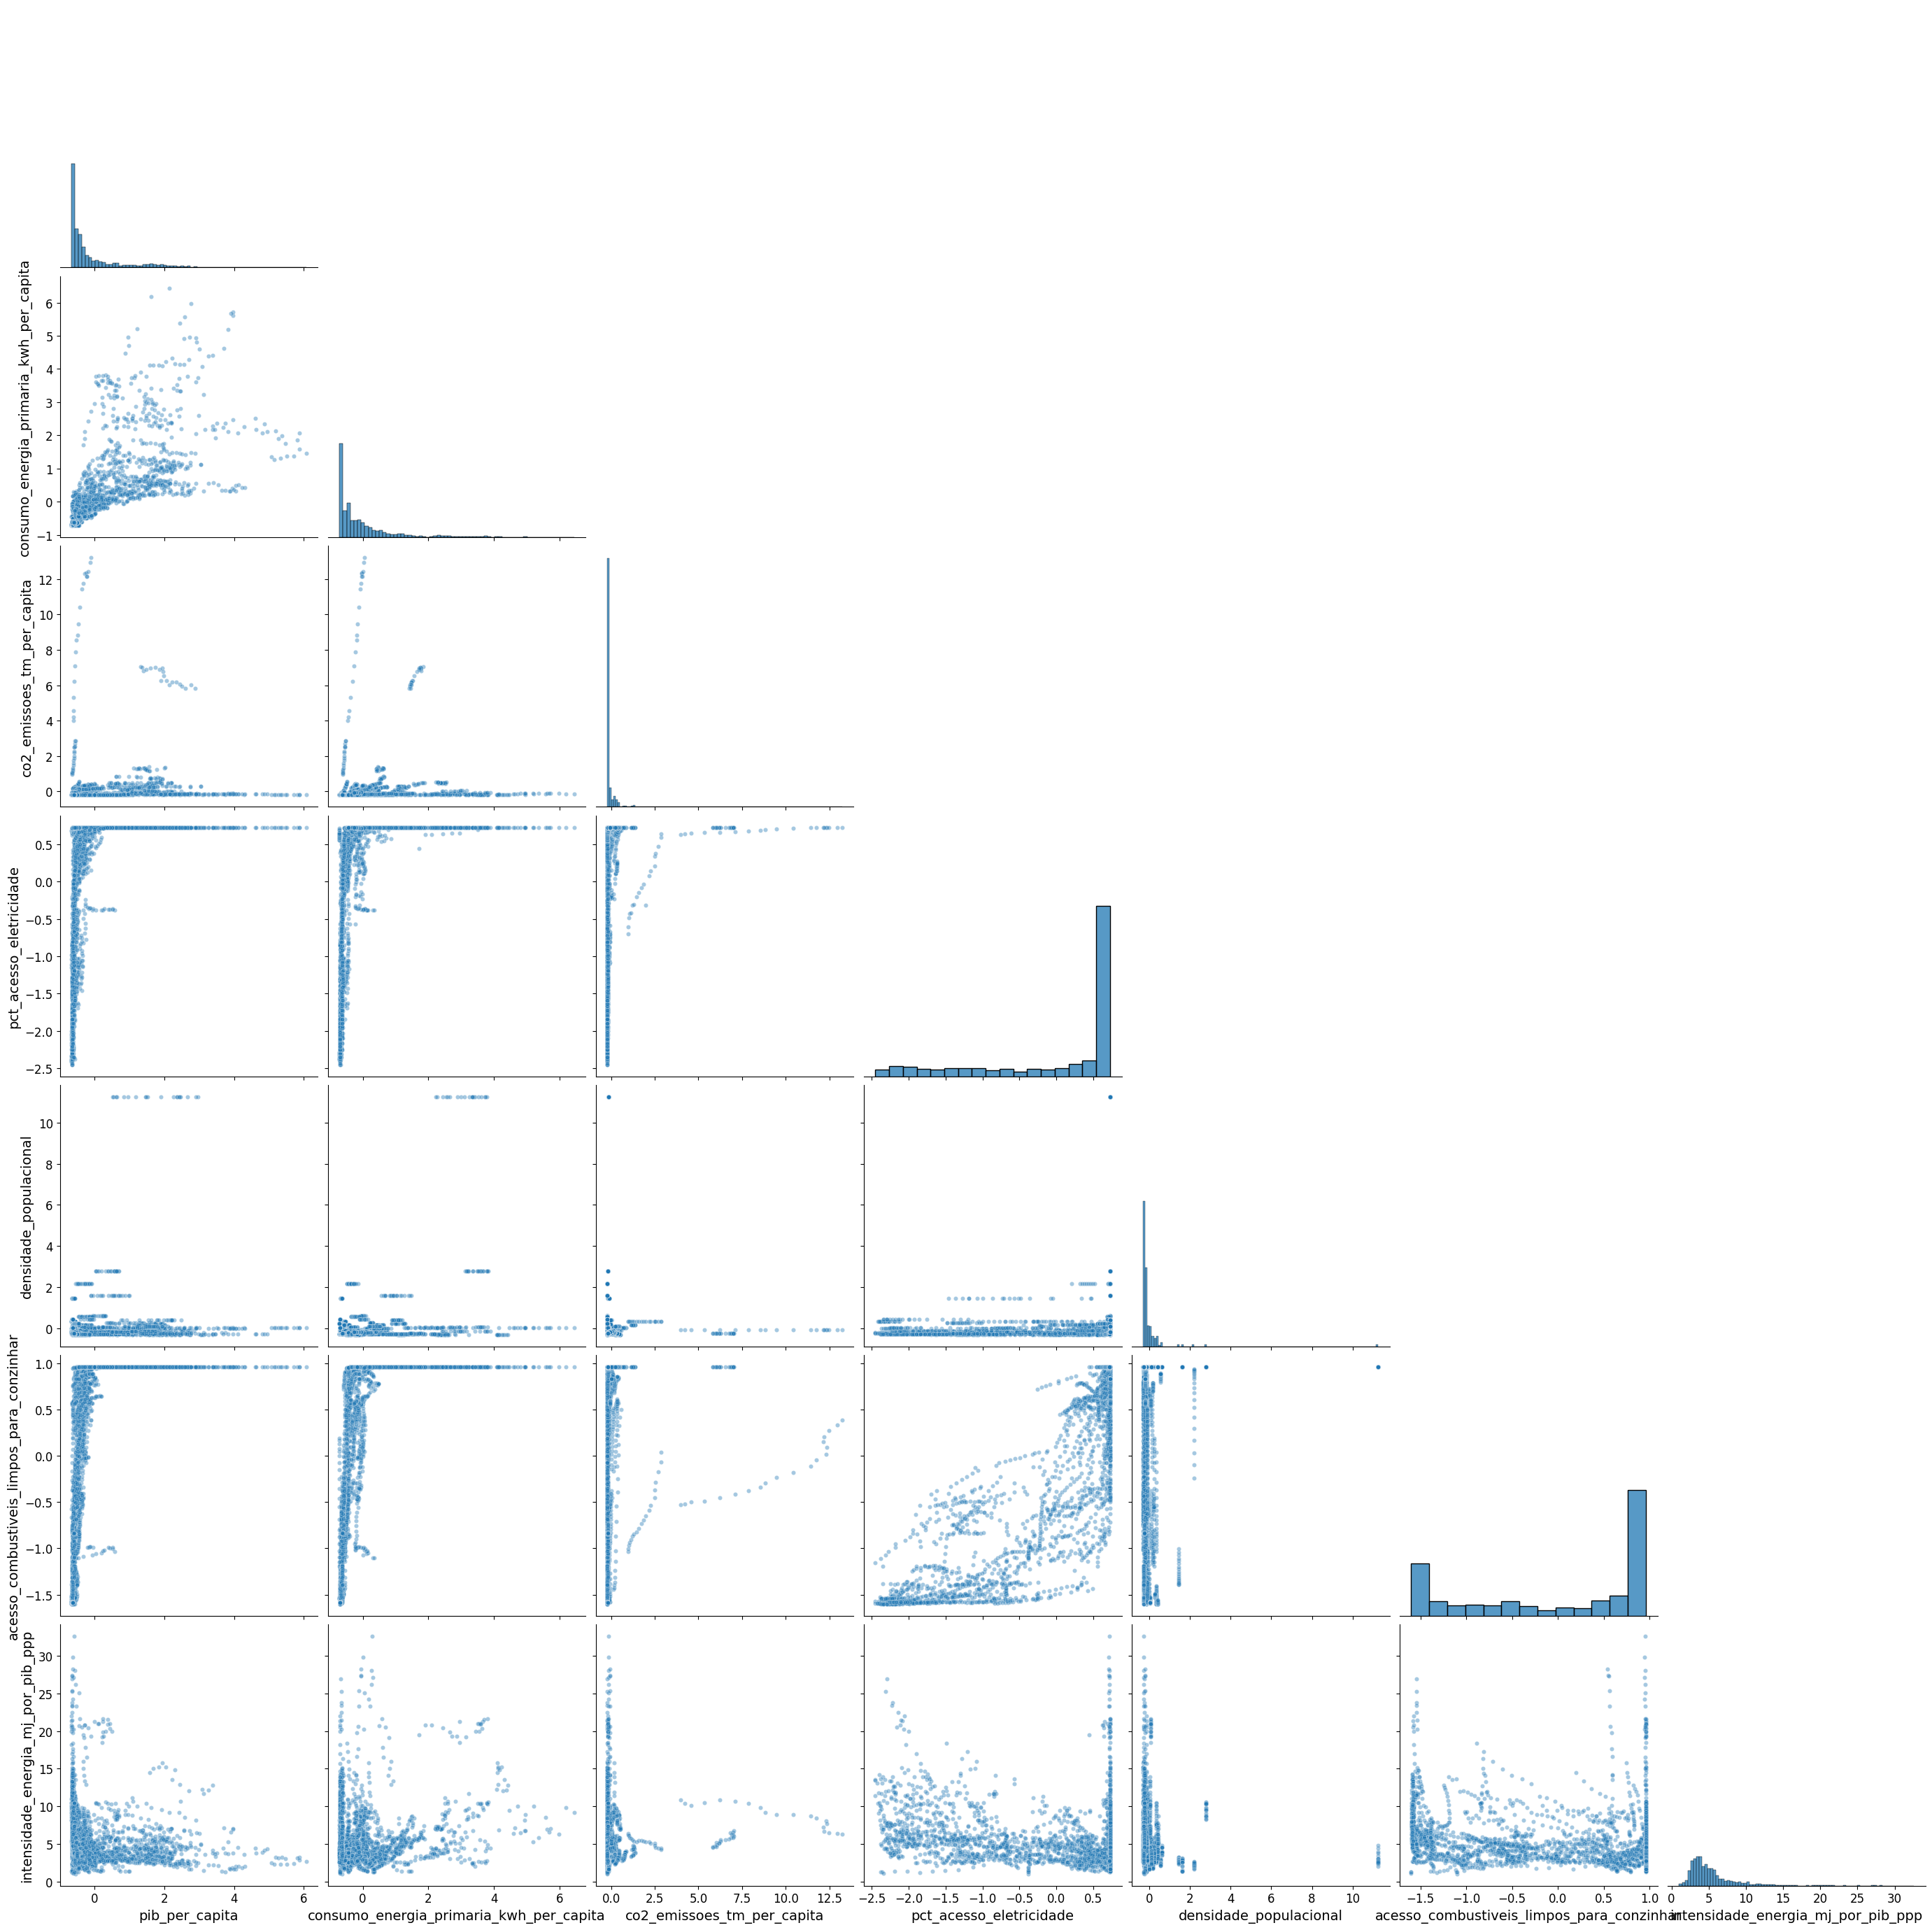

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

cols.remove("intensidade_energia_mj_por_pib_ppp")
scaler = StandardScaler()
df_energy_filtrado[cols] = scaler.fit_transform(df_energy_filtrado[cols])
cols.append("intensidade_energia_mj_por_pib_ppp")

g = sns.pairplot(
    df_energy_filtrado,
    vars=cols,
    corner=True,
    height=4,
    plot_kws={
        "alpha": 0.4,
        "s": 20
    }
)

#  AUMENTAR TAMANHO DOS RÓTULOS DOS EIXOS
for ax in g.axes.flatten():
    if ax is not None:
        ax.tick_params(axis='both', labelsize=12)  # números dos eixos

#  AUMENTAR NOME DAS VARIÁVEIS (labels)
for ax in g.axes[-1, :]:
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), fontsize=14)

for ax in g.axes[:, 0]:
    if ax is not None:
        ax.set_ylabel(ax.get_ylabel(), fontsize=14)

plt.show()

### Relações lineares entre variáveis numéricas
 A matriz de correlação de Spearman entre as variáveis numéricas do dataset. O objetivo é identificar relações lineares fortes que possam informar próximas etapas (e.g., seleção de variáveis, multicolinearidade, ou insights de causa/efeito possível).

Pontos importantes:
- O coeficiente de Pearson varia de -1 a 1; 1 indica correlação positiva perfeita, -1 correlação negativa perfeita, e 0 nenhuma correlação linear.
- Correlação não implica causalidade: use estes resultados apenas como sinalizadores.
- Atenção a colinearidade: variáveis fortemente correlacionadas podem distorcer modelos que supõem independência entre variáveis (e.g., regressão).

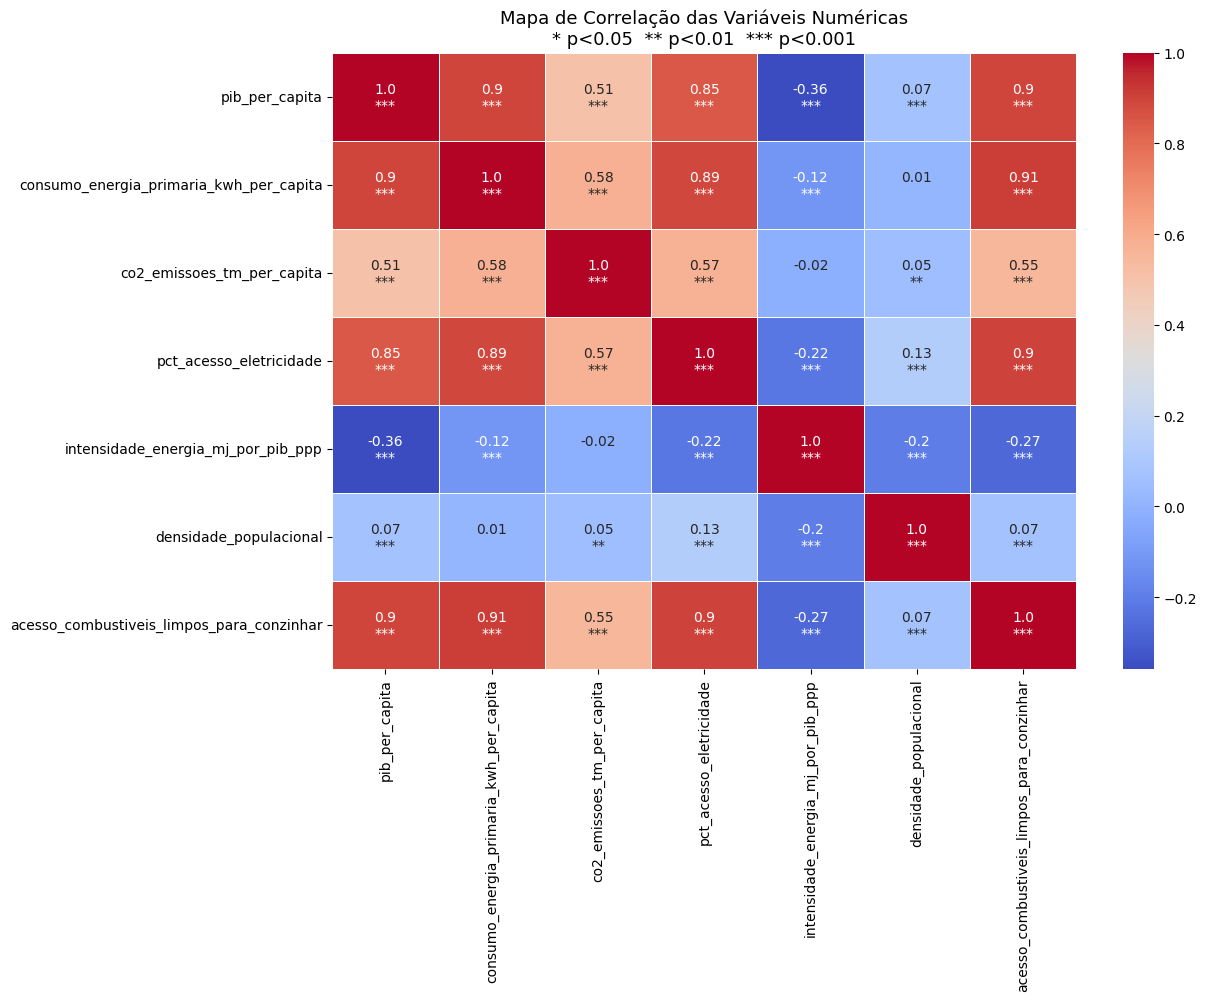

In [29]:
from scipy.stats import spearmanr
import numpy as np

# Calcula correlação e p-valores
corr = df_energy_filtrado.corr(numeric_only=True, method="spearman")
df_num = df_energy_filtrado.select_dtypes(include="number")
pval = pd.DataFrame(
    spearmanr(df_num, nan_policy="omit").pvalue,
    columns=corr.columns, index=corr.index
)

# Cria anotações com asteriscos
def significancia(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return ""

annot = corr.round(2).astype(str) + "\n" + pval.map(significancia)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=annot, cmap='coolwarm', fmt='', linewidths=0.5)
plt.title("Mapa de Correlação das Variáveis Numéricas\n* p<0.05  ** p<0.01  *** p<0.001", fontsize=13)
plt.show()

Diante das variáveis selecionadas, observa-se uma forte relação entre o **Produto Interno Bruto (PIB) per capita**, o **consumo de energia primária por habitante**, o **percentual da população com acesso à eletricidade** e o **percentual da população com acesso a combustíveis limpos para cozinhar**, uma vez que essas variáveis apresentam elevada correlação entre si.

Considerando essa alta correlação, optou-se por analisar o **Fator de Inflação da Variância (VIF)** do modelo, a fim de verificar se esse indício de **multicolinearidade** se confirma. Essa análise é importante para evitar possíveis problemas ou distorções nas estimativas dos parâmetros do modelo.


In [30]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

colunas_x = cols
X = df_energy_filtrado[colunas_x]
X = sm.add_constant(X)

vif_df = pd.DataFrame()
vif_df["Variável"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) 
                 for i in range(X.shape[1])]

print(vif_df.sort_values("VIF", ascending=False))


                                    Variável       VIF
6  acesso_combustiveis_limpos_para_conzinhar  4.846732
0                                      const  4.319037
4                    pct_acesso_eletricidade  4.265886
2    consumo_energia_primaria_kwh_per_capita  3.077760
1                             pib_per_capita  2.504731
7         intensidade_energia_mj_por_pib_ppp  1.407141
5                     densidade_populacional  1.169316
3                 co2_emissoes_tm_per_capita  1.038134


Aparentemente, apenas o **percentual de acesso a combustíveis limpos para cozinhar** e o **percentual de acesso à eletricidade** se aproximaram do limite considerado crítico para o **Fator de Inflação da Variância (VIF)**. Contudo, de forma criteriosa, optou-se por prosseguir com a análise **sem a exclusão dessas variáveis**, uma vez que os valores ainda não ultrapassaram o limite estabelecido para caracterizar multicolinearidade problemática no modelo.


In [31]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

# Reinicia o índice do dataframe
df_energy_filtrado = df_energy_filtrado.reset_index(drop=True)

# Fórmula do modelo
formula = """
intensidade_energia_mj_por_pib_ppp ~
pct_acesso_eletricidade +
pib_per_capita +
consumo_energia_primaria_kwh_per_capita +
co2_emissoes_tm_per_capita +
densidade_populacional
"""

# Ajuste do modelo GLM com família Gamma e link log
modelo = smf.glm(
    formula=formula,
    data=df_energy_filtrado,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                         Generalized Linear Model Regression Results                          
==============================================================================================
Dep. Variable:     intensidade_energia_mj_por_pib_ppp   No. Observations:                 3026
Model:                                            GLM   Df Residuals:                     3020
Model Family:                                   Gamma   Df Model:                            5
Link Function:                                    Log   Scale:                         0.23828
Method:                                          IRLS   Log-Likelihood:                -6438.4
Date:                                ter, 24 mar 2026   Deviance:                       529.32
Time:                                        14:17:43   Pearson chi2:                     720.
No. Iterations:                                    21   Pseudo R-squ. (CS):             0.3836
Covariance Type:                            nonrobust                                         
===========================================================================================================
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                   1.6265      0.009    183.293      0.000       1.609       1.644
pct_acesso_eletricidade                    -0.2311      0.010    -22.730      0.000      -0.251      -0.211
pib_per_capita                             -0.3022      0.013    -23.554      0.000      -0.327      -0.277
consumo_energia_primaria_kwh_per_capita     0.4215      0.014     31.205      0.000       0.395       0.448
co2_emissoes_tm_per_capita                  0.0555      0.009      6.177      0.000       0.038       0.073
densidade_populacional                     -0.1253      0.009    -13.368      0.000      -0.144      -0.107
===========================================================================================================
"""

<!-- - **Predito vs Observado** Observa-se que a maioria dos pontos está concentrada em valores baixos, indicando que o modelo consegue capturar bem os países com menor intensidade energética. Alguns pontos com valores altos estão acima da linha de 45°, sugerindo que o modelo tende a subestimar a intensidade energética em países com valores muito elevados.

- **Resíduos de Pearson vs Valores Ajustados** Há uma dispersão relativamente homogênea dos resíduos ao longo dos valores ajustados, o que é esperado em modelos Gamma. Alguns resíduos estão próximos de ±2, confirmando a presença de observações com intensidade energética inesperadamente alta em relação ao que o modelo prevê.

- **Histograma dos Resíduos Desviance** A distribuição é ligeiramente assimétrica à direita, sugerindo a presença de valores extremos — países com intensidade energética muito elevada. A maioria dos resíduos está concentrada dentro de ±2 desvios, mas as caudas longas reforçam a necessidade de atenção às observações influentes identificadas anteriormente.

- **QQ-Plot dos Resíduos Desviance** A parte central segue aproximadamente a linha teórica, indicando um ajuste razoável do modelo. Nas extremidades, no entanto, há desvios, indicando que os resíduos não seguem perfeitamente a distribuição esperada. Isso é comum em modelos Gamma quando há observações com valores muito discrepantes, como os países identificados na análise de influência. -->

### serão usadas três métricas:

* Resíduo studentizado/padronizado — mede o quão mal o modelo prevê aquela observação. Um valor grande indica que o ponto é um outlier na variável resposta (Y).
  
* Leverage (alavancagem) — mede o quão "extrema" é a observação em termos das variáveis preditoras (X). Um ponto com leverage alto fica longe do centro dos dados, tendo potencial para influenciar o modelo.
  
* Distância de Cook — combina os dois anteriores. Mede o impacto real daquela observação nos coeficientes estimados. É a métrica mais importante para identificar influênci

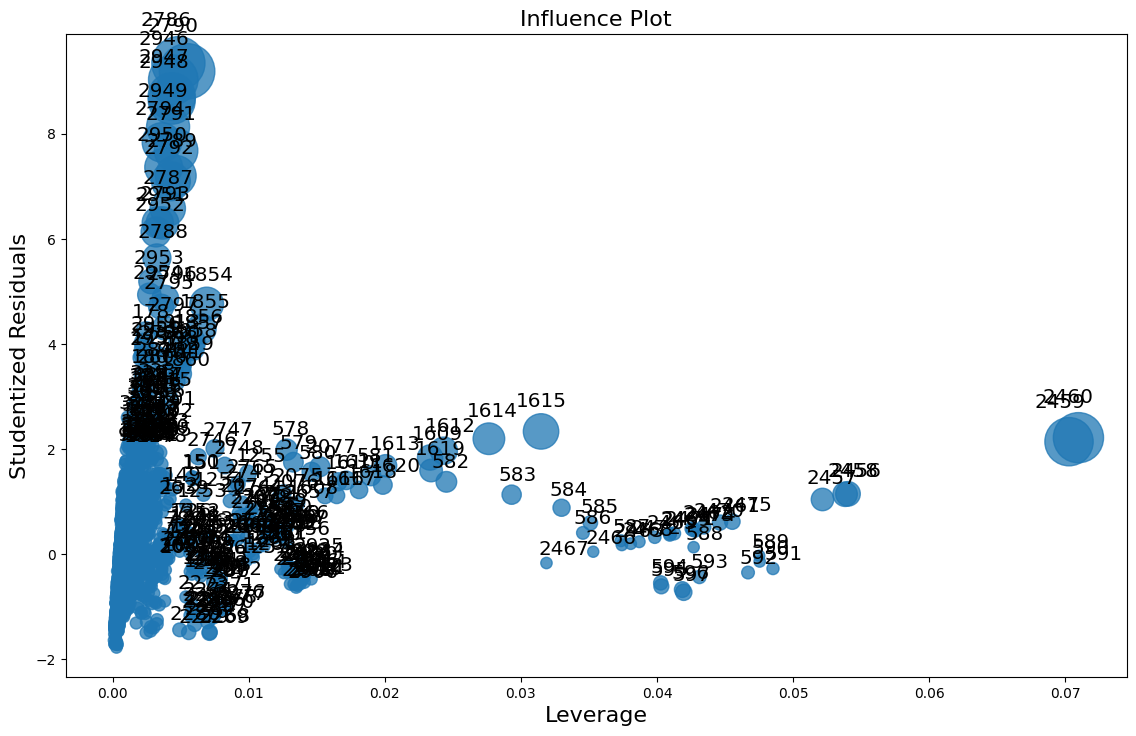

In [32]:
fig, ax = plt.subplots(figsize = (12, 8))
infl = modelo.get_influence(observed=True)
fig = infl.plot_influence(size = 40, ax = ax)
fig.tight_layout(pad=3.0)


Percebemos que há uma parcela de observações com **leverage** (alavancagem), ou seja, pontos de alavancagem relativamente altos. Além disso, observa-se uma grande concentração de valores entre 0 e 0,10, acompanhada de resíduos studentizados muito elevados. Isso já é um indício de que temos diversas observações que podem estar influenciando excessivamente o ajuste do modelo, prejudicando sua estabilidade e qualidade inferencial.

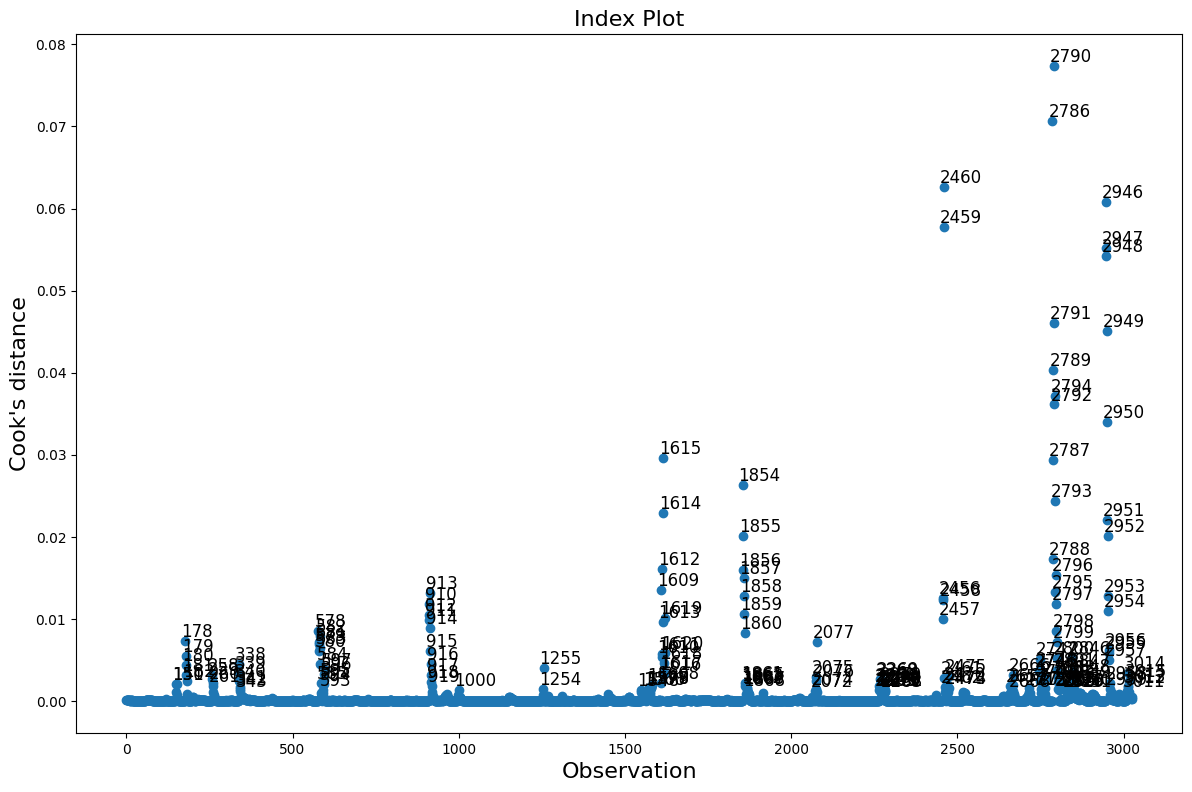

In [33]:
fig = infl.plot_index(y_var="cooks", threshold=2 * infl.cooks_distance[0].mean())
fig.set_size_inches(12, 8)
fig.tight_layout(pad=1.0)

Com o mesmo propósito de identificar observações excessivamente problemáticas, optou-se pela visualização da Distância de Cook. Por meio desse gráfico, é possível identificar claramente dois clusters de observações influentes que impactam de forma considerável a estimação dos parâmetros do modelo. Com base nessa análise, foram removidas apenas as observações que apresentaram simultaneamente uma Distância de Cook elevada e resíduos studentizados altos, por serem as que de fato comprometem a qualidade do ajuste.

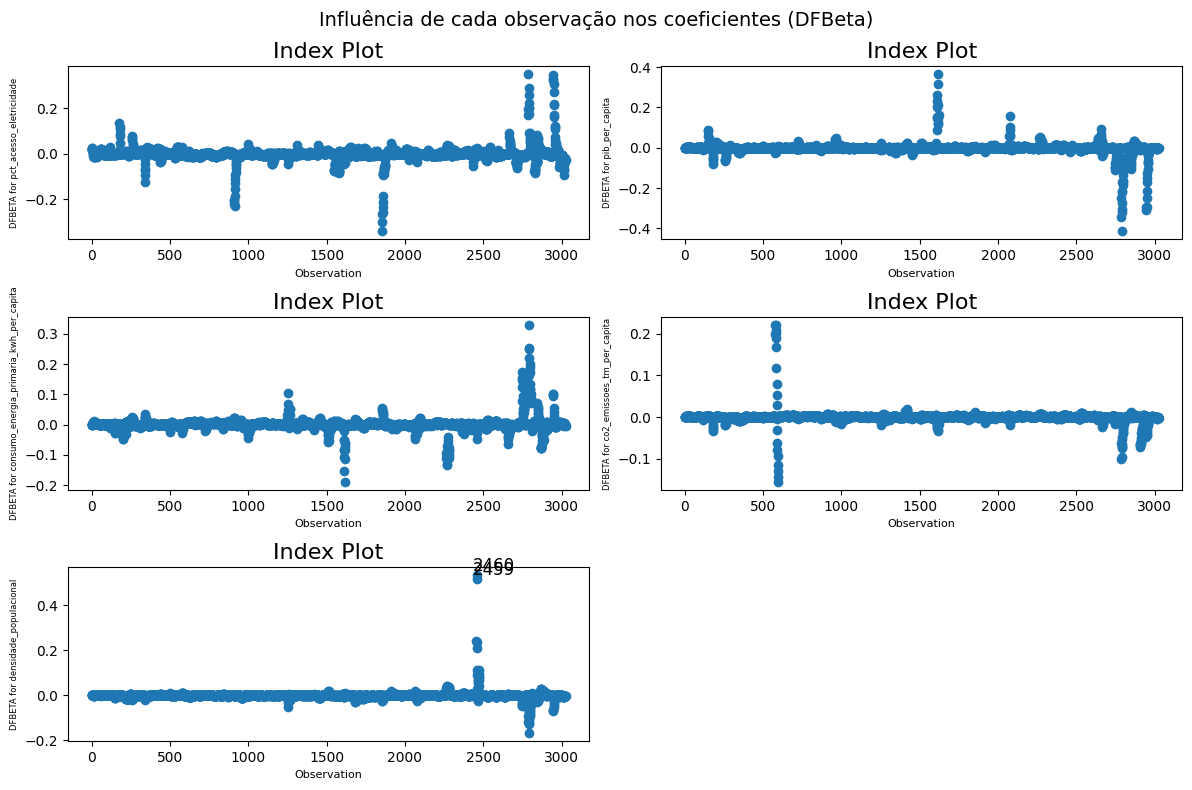

In [34]:
a = [1, 2, 3, 4,5]
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 8))
axes_flat = axes.flatten()

for i, ax in zip(a, axes_flat):
    infl.plot_index(y_var="dfbeta", idx=i, threshold=0.5, ax=ax)
    ax.yaxis.label.set_size(6)   # aplica em cada subplot dentro do loop
    ax.xaxis.label.set_size(8)

plt.suptitle("Influência de cada observação nos coeficientes (DFBeta)", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.subplots_adjust(hspace=0.5)

axes_flat[-1].set_visible(False)
fig.tight_layout(pad=1.0)
plt.show()

In [35]:
influence = modelo.get_influence()
n, p = modelo.nobs, modelo.df_model

flags = (
    (influence.cooks_distance[0] > 4/n) |
    (np.abs(influence.resid_studentized) > 3) |
    (influence.hat_matrix_diag > 2*(p+1)/n)
)

conflitantes = np.where(flags)[0]

 A fim de garantir a robustez do modelo, procedeu-se à identificação e **retirada** de observações influentes e outliers com base em três critérios diagnósticos complementares. A **Distância de Cook** (limiar: 4/n) avalia o impacto de cada observação nos coeficientes estimados como um todo. Os **resíduos studentizados** (|r| > 3) detectam pontos com erro de ajuste atipicamente elevado. Por fim, a **matriz hat** (limiar: 2(p+1)/n) identifica pontos de alavancagem, isto é, observações com valores extremos nas variáveis preditoras. Foram removidas da amostra apenas as observações que violaram **simultaneamente os três critérios**, garantindo que somente os casos inequivocamente problemáticos fossem excluídos da estimação final do modelo.

In [36]:
# Remover e reajustar
df_energy_filtrado = df_energy_filtrado.drop(index=conflitantes)

modelo = smf.glm(
    formula,
    data=df_energy_filtrado,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                         Generalized Linear Model Regression Results                          
==============================================================================================
Dep. Variable:     intensidade_energia_mj_por_pib_ppp   No. Observations:                 2742
Model:                                            GLM   Df Residuals:                     2736
Model Family:                                   Gamma   Df Model:                            5
Link Function:                                    Log   Scale:                         0.11446
Method:                                          IRLS   Log-Likelihood:                -5021.4
Date:                                ter, 24 mar 2026   Deviance:                       320.29
Time:                                        14:18:02   Pearson chi2:                     313.
No. Iterations:                                    15   Pseudo R-squ. (CS):             0.4653
Covariance Type:                            nonrobust                                         
===========================================================================================================
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                   1.5491      0.007    214.244      0.000       1.535       1.563
pct_acesso_eletricidade                    -0.2304      0.008    -30.158      0.000      -0.245      -0.215
pib_per_capita                             -0.2806      0.014    -20.178      0.000      -0.308      -0.253
consumo_energia_primaria_kwh_per_capita     0.3791      0.016     24.144      0.000       0.348       0.410
co2_emissoes_tm_per_capita                  0.1954      0.025      7.709      0.000       0.146       0.245
densidade_populacional                     -0.2790      0.019    -14.453      0.000      -0.317      -0.241
===========================================================================================================
"""

Tendo em vista a significância da variávels, optamos não por removê-las da modelagem e, com isso, prosseguimos com as interpretações dos coeficientes do modelo gamma.

In [37]:
from matplotlib.pylab import exp #ou
table_df = exp(modelo.params).round(2)
table_df = table_df.reset_index()
table_df.columns = ["Variável", "Odds Ratio"]
table_df.style.format({"Odds Ratio": "{:.2f}"}) \
              .set_caption("Odds Ratio dos Coeficientes") \
              .hide(axis="index")

Variável,Odds Ratio
Intercept,4.71
pct_acesso_eletricidade,0.79
pib_per_capita,0.76
consumo_energia_primaria_kwh_per_capita,1.46
co2_emissoes_tm_per_capita,1.22
densidade_populacional,0.76


In [38]:
from numpy import exp

table_df = exp(modelo.conf_int())

table_df = table_df.reset_index()
table_df.columns = ["Variável", "IC 2.5%", "IC 97.5%"]

table_df.style.format({
    "IC 2.5%": "{:.3f}",
    "IC 97.5%": "{:.3f}"
}).set_caption("Intervalo de Confiança (95%)").hide(axis="index")

Variável,IC 2.5%,IC 97.5%
Intercept,4.641,4.774
pct_acesso_eletricidade,0.782,0.806
pib_per_capita,0.735,0.776
consumo_energia_primaria_kwh_per_capita,1.417,1.507
co2_emissoes_tm_per_capita,1.157,1.278
densidade_populacional,0.728,0.786


# Interpretação dos parâmetros do modelo

- No modelo de regressão Gamma com função de ligação log, os coeficientes estimados são interpretados na escala exponencial por meio de $ \exp(\beta) $, representando **fatores multiplicativos sobre a média condicional da intensidade energética**. Assim, valores maiores que 1 indicam aumento esperado na intensidade energética, enquanto valores menores que 1 indicam redução, mantendo as demais variáveis constantes.


- O intercepto transformado apresenta valor aproximado de **4,70**, com intervalo de confiança de **[4,64 ; 4,77]**. Esse valor representa a média esperada da intensidade energética quando todas as covariáveis assumem valor zero. Embora essa interpretação raramente tenha significado prático direto, o intercepto é necessário para a correta especificação do modelo.


- Para o **percentual da população com acesso à eletricidade**, o fator multiplicativo estimado é aproximadamente **0,79**, com intervalo de confiança de **[0,78 ; 0,81]**. Esse resultado indica que aumentos no acesso à eletricidade estão associados a uma **redução na média esperada da intensidade energética em 20%**


- O **PIB per capita** apresenta fator multiplicativo aproximado de **0,76**, com intervalo de confiança de **[0,74 ; 0,78]**. Isso indica que níveis mais elevados de renda média estão associados a uma **redução na média esperada da intensidade energética em 25%**, o que pode refletir economias mais eficientes do ponto de vista tecnológico e energético.


- O **consumo de energia primária per capita** apresenta fator multiplicativo estimado de **1,46**, com intervalo de confiança de **[1,42 ; 1,51]**. Esse resultado indica que aumentos no consumo de energia estão associados a **maior intensidade energética, ou seja, aumento na média esperada da intensidade energética em 46%**, sugerindo que economias com maior consumo energético por habitante tendem a utilizar mais energia para gerar riqueza.


- As **emissões de CO₂ per capita** apresentam fator multiplicativo aproximado de **1,22**, com intervalo de confiança de **[1,16 ; 1,28]**. Esse resultado indica que níveis mais elevados de emissões estão associados a **maiores níveis de intensidade energética, ou seja, aumento na média esperada da intensidade energética em 21%**, refletindo a relação entre uso intensivo de energia e impacto ambiental.


- Por fim, a **densidade populacional** apresenta fator multiplicativo estimado de **0,76**, com intervalo de confiança de **[0,73 ; 0,79]**. Isso indica que maiores densidades populacionais estão associadas a **menor intensidade energética**, possivelmente devido a ganhos de eficiência decorrentes da concentração urbana e do uso mais eficiente da infraestrutura energética.


